# Comprehensive Analysis of All Trained Models

This notebook:
1. Loads all trained models (V2S, ConvNeXt, ViT)
2. Generates test predictions from each
3. Compares training histories
4. Analyzes prediction diversity
5. Visualizes model differences
6. Prepares for ensemble (to be added later)

Usage:
    python analyze_all_models.py

In [1]:
import pandas as pd
import numpy as np
import h5py
from pathlib import Path
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_v2_s, convnext_base, vit_b_16
from PIL import Image
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import json
from datetime import datetime

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}\n")

Using device: cuda



In [2]:
# ===========================
# CONFIGURATION - SET YOUR MODEL DIRECTORIES
# ===========================

print("="*70)
print("MODEL ANALYSIS CONFIGURATION")
print("="*70 + "\n")

# Auto-detect latest model directories
results_base = Path('results')

# Find latest for each model type
v2s_dirs = sorted(results_base.glob('v2s_features_*'))
convnext_dirs = sorted(results_base.glob('convnext_features_*'))
vit_dirs = sorted(results_base.glob('vit_features_*'))

V2S_DIR = v2s_dirs[-1] if v2s_dirs else None
CONVNEXT_DIR = convnext_dirs[-1] if convnext_dirs else None
VIT_DIR = vit_dirs[-1] if vit_dirs else None

print("Model directories detected:")
print(f"  V2S + Features:     {V2S_DIR}")
print(f"  ConvNeXt + Features: {CONVNEXT_DIR}")
print(f"  ViT + Features:      {VIT_DIR}")
print()

# Check which models are available
has_v2s = V2S_DIR is not None and V2S_DIR.exists()
has_convnext = CONVNEXT_DIR is not None and CONVNEXT_DIR.exists()
has_vit = VIT_DIR is not None and VIT_DIR.exists()

print("Models available:")
print(f"  ✓ V2S" if has_v2s else "  ✗ V2S (not found)")
print(f"  ✓ ConvNeXt" if has_convnext else "  ✗ ConvNeXt (not found)")
print(f"  ✓ ViT" if has_vit else "  ✗ ViT (not found)")
print()

if not any([has_v2s, has_convnext, has_vit]):
    print("❌ No models found! Train models first.")
    exit(1)

print("="*70 + "\n")

MODEL ANALYSIS CONFIGURATION

Model directories detected:
  V2S + Features:     results/v2s_features_20251110_155122
  ConvNeXt + Features: results/convnext_features_20251110_155952
  ViT + Features:      results/vit_features_20251110_180138

Models available:
  ✓ V2S
  ✓ ConvNeXt
  ✓ ViT




In [3]:
# ===========================
# FEATURE ENGINEERING (MUST MATCH TRAINING)
# ===========================

def engineer_features(df):
    """Same feature engineering used in training"""
    df = df.copy()
    
    df['age_group'] = pd.cut(df['age_approx'], bins=[0, 30, 50, 70, 100],
                             labels=['young', 'middle', 'senior', 'elderly'])
    df['age_risk'] = (df['age_approx'] > 50).astype(int)
    
    df['lesion_size_mm'] = df['clin_size_long_diam_mm'].fillna(df['tbp_lv_minorAxisMM'])
    df['size_category'] = pd.cut(df['lesion_size_mm'], bins=[0, 6, 10, 20, 100],
                                 labels=['small', 'medium', 'large', 'very_large'])
    df['large_lesion'] = (df['lesion_size_mm'] > 6).astype(int)
    
    df['shape_regularity'] = df['tbp_lv_areaMM2'] / (df['tbp_lv_perimeterMM']**2 + 1e-6)
    df['eccentricity'] = df['tbp_lv_minorAxisMM'] / (df['tbp_lv_areaMM2']**0.5 + 1e-6)
    
    df['color_variance'] = np.sqrt(
        df['tbp_lv_deltaB']**2 + df['tbp_lv_radial_color_std_max']**2 +
        df['tbp_lv_color_std_mean']**2
    )
    df['color_uniformity'] = 1 / (df['tbp_lv_norm_color'] + 1e-6)
    df['darkness_score'] = df['tbp_lv_B'] / (df['tbp_lv_H'] + 1e-6)
    
    high_risk_sites = ['torso', 'upper extremity', 'posterior torso', 'anterior torso']
    df['high_risk_site'] = df['anatom_site_general'].isin(high_risk_sites).astype(int)
    
    site_risk_map = {
        'torso': 3, 'posterior torso': 3, 'anterior torso': 3,
        'upper extremity': 2, 'lower extremity': 2, 'head/neck': 2,
        'palms/soles': 1, 'oral/genital': 1
    }
    df['site_risk_score'] = df['anatom_site_general'].map(site_risk_map).fillna(0)
    
    df['age_size_risk'] = df['age_approx'] * df['lesion_size_mm']
    df['age_site_risk'] = df['age_approx'] * df['high_risk_site']
    df['color_size_risk'] = df['color_variance'] * df['lesion_size_mm']
    
    df['asymmetry_score'] = (
        df['tbp_lv_norm_color'] + df['tbp_lv_radial_color_std_max'] +
        (1 / (df['shape_regularity'] + 1e-6))
    ) / 3
    
    df['log_area'] = np.log1p(df['tbp_lv_areaMM2'])
    df['log_perimeter'] = np.log1p(df['tbp_lv_perimeterMM'])
    df['log_size'] = np.log1p(df['lesion_size_mm'])
    
    df['h_to_b_ratio'] = df['tbp_lv_H'] / (df['tbp_lv_B'] + 1e-6)
    df['a_to_b_ratio'] = df['tbp_lv_A'] / (df['tbp_lv_B'] + 1e-6)
    
    return df


def preprocess_metadata_with_features(df, scaler, encoders):
    """Preprocess test metadata using saved scaler/encoders"""
    df = engineer_features(df)
    
    NUMERICAL_FEATURES = [
        'tbp_lv_H', 'tbp_lv_areaMM2', 'tbp_lv_minorAxisMM',
        'tbp_lv_perimeterMM', 'tbp_lv_deltaB', 'tbp_lv_Hext',
        'clin_size_long_diam_mm', 'tbp_lv_radial_color_std_max',
        'tbp_lv_B', 'tbp_lv_color_std_mean', 'tbp_lv_Aext',
        'tbp_lv_stdLExt', 'tbp_lv_norm_color', 'tbp_lv_A', 'age_approx',
        'lesion_size_mm', 'shape_regularity', 'eccentricity',
        'color_variance', 'color_uniformity', 'darkness_score',
        'site_risk_score', 'age_size_risk', 'age_site_risk',
        'color_size_risk', 'asymmetry_score',
        'log_area', 'log_perimeter', 'log_size',
        'h_to_b_ratio', 'a_to_b_ratio'
    ]
    
    CATEGORICAL_FEATURES = [
        'sex', 'anatom_site_general', 'tbp_tile_type', 'tbp_lv_location_simple',
        'age_group', 'size_category', 'age_risk', 'large_lesion', 'high_risk_site'
    ]
    
    for col in NUMERICAL_FEATURES:
        if col in df.columns:
            df[col] = df[col].fillna(0)
    
    for col in CATEGORICAL_FEATURES:
        if col in df.columns:
            df[col] = df[col].astype(str).fillna('missing')
    
    df[NUMERICAL_FEATURES] = scaler.transform(df[NUMERICAL_FEATURES])
    
    encoded_dfs = []
    for col in CATEGORICAL_FEATURES:
        encoded = pd.get_dummies(df[col], prefix=col, dtype=float)
        for train_col in encoders[col]:
            if train_col not in encoded.columns:
                encoded[train_col] = 0
        encoded = encoded[encoders[col]]
        encoded_dfs.append(encoded)
    
    result_df = pd.concat([df[NUMERICAL_FEATURES]] + encoded_dfs, axis=1)
    return result_df

In [4]:
# ===========================
# DATASET CLASS
# ===========================

class HybridDataset(Dataset):
    def __init__(self, hdf5_path, metadata_df, transform=None):
        self.hdf5_path = hdf5_path
        self.transform = transform
        self.hdf5_file = None
        
        with h5py.File(hdf5_path, 'r') as f:
            available_ids = set(f.keys())
        
        self.metadata = metadata_df[
            metadata_df['isic_id'].isin(available_ids)
        ].reset_index(drop=True)
        
        feature_cols = [col for col in self.metadata.columns if col != 'isic_id']
        self.metadata_features = self.metadata[feature_cols].values.astype(np.float32)
    
    def _ensure_hdf5_open(self):
        if self.hdf5_file is None:
            self.hdf5_file = h5py.File(self.hdf5_path, 'r', swmr=True)
    
    def __len__(self):
        return len(self.metadata)
    
    def __getitem__(self, idx):
        self._ensure_hdf5_open()
        
        row = self.metadata.iloc[idx]
        image_id = row['isic_id']
        
        img_array = self.hdf5_file[image_id][:]
        image = Image.fromarray(img_array)
        
        if self.transform:
            image = self.transform(image)
        
        metadata = torch.tensor(self.metadata_features[idx], dtype=torch.float32)
        return image, metadata, image_id

In [5]:
# ===========================
# MODEL ARCHITECTURES
# ===========================

class MetadataProcessor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
    
    def forward(self, x):
        return self.fc(x)


class EfficientNetV2Hybrid(nn.Module):
    def __init__(self, metadata_dim):
        super().__init__()
        self.efficientnet = efficientnet_v2_s(weights='IMAGENET1K_V1')
        self.efficientnet.classifier = nn.Identity()
        
        total_params = len(list(self.efficientnet.parameters()))
        freeze_until = int(total_params * 0.8)
        for idx, param in enumerate(self.efficientnet.parameters()):
            if idx < freeze_until:
                param.requires_grad = False
        
        self.metadata_processor = MetadataProcessor(metadata_dim)
        
        self.classifier = nn.Sequential(
            nn.Linear(1280 + 64, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )
    
    def forward(self, image, metadata):
        img_features = self.efficientnet(image)
        meta_features = self.metadata_processor(metadata)
        combined = torch.cat([img_features, meta_features], dim=1)
        return self.classifier(combined)


class ConvNeXtHybrid(nn.Module):
    def __init__(self, metadata_dim):
        super().__init__()
        
        convnext = convnext_base(weights='IMAGENET1K_V1')
        self.features = convnext.features
        self.avgpool = convnext.avgpool
        self.layer_norm = convnext.classifier[0]
        
        total_blocks = len(self.features)
        freeze_until = int(total_blocks * 0.7)
        for idx, block in enumerate(self.features):
            if idx < freeze_until:
                for param in block.parameters():
                    param.requires_grad = False
        
        self.metadata_processor = MetadataProcessor(metadata_dim)
        
        self.classifier = nn.Sequential(
            nn.Linear(1024 + 64, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 1)
        )
    
    def forward(self, image, metadata):
        x = self.features(image)
        x = self.avgpool(x)
        x = self.layer_norm(x)
        img_features = x.flatten(1)
        
        meta_features = self.metadata_processor(metadata)
        combined = torch.cat([img_features, meta_features], dim=1)
        return self.classifier(combined)


class ViTHybrid(nn.Module):
    def __init__(self, metadata_dim):
        super().__init__()
        
        vit = vit_b_16(weights='IMAGENET1K_V1')
        self.conv_proj = vit.conv_proj
        self.encoder = vit.encoder
        
        for idx, block in enumerate(self.encoder.layers):
            if idx < 6:
                for param in block.parameters():
                    param.requires_grad = False
        
        self.metadata_processor = MetadataProcessor(metadata_dim)
        
        self.classifier = nn.Sequential(
            nn.Linear(768 + 64, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 1)
        )
    
    def forward(self, image, metadata):
        x = self.conv_proj(image)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        
        batch_class_token = self.encoder.pos_embedding[:, :1, :].expand(B, -1, -1)
        x = torch.cat([batch_class_token, x], dim=1)
        x = x + self.encoder.pos_embedding
        x = self.encoder.dropout(x)
        x = self.encoder.layers(x)
        x = self.encoder.ln(x)
        
        img_features = x[:, 0]
        meta_features = self.metadata_processor(metadata)
        
        combined = torch.cat([img_features, meta_features], dim=1)
        return self.classifier(combined)

In [6]:
# ===========================
# LOAD TEST DATA
# ===========================

print("="*70)
print("LOADING TEST DATA")
print("="*70 + "\n")

data_dir = Path('data')
test_meta = pd.read_csv(data_dir / 'students-test-metadata.csv', low_memory=False)

print(f"✓ Test metadata loaded: {len(test_meta)} samples\n")

# Transform (no augmentation for test)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

LOADING TEST DATA

✓ Test metadata loaded: 100 samples



In [7]:
# ===========================
# SECTION 1: EFFICIENTNETV2-S + FEATURES
# ===========================

print("\n" + "="*70)
print("SECTION 1: EFFICIENTNETV2-S + FEATURES")
print("="*70 + "\n")

v2s_results = {}

if has_v2s:
    print(f"Loading from: {V2S_DIR}\n")
    
    # Load training results
    with open(V2S_DIR / 'training_results.pkl', 'rb') as f:
        v2s_train_results = pickle.load(f)
    
    print("Training Summary:")
    print(f"  Best Val AUC: {v2s_train_results['best_auc']:.4f}")
    print(f"  Training time: {v2s_train_results['total_time']/60:.1f} minutes")
    print(f"  Metadata dim: {v2s_train_results['metadata_dim']}")
    print()
    
    # Load preprocessors
    with open(V2S_DIR / 'preprocessors.pkl', 'rb') as f:
        v2s_preprocessors = pickle.load(f)
    
    # Preprocess test metadata
    test_meta_v2s = preprocess_metadata_with_features(
        test_meta, 
        scaler=v2s_preprocessors['scaler'],
        encoders=v2s_preprocessors['encoders']
    )
    test_meta_v2s['isic_id'] = test_meta['isic_id'].values
    
    # Create test dataset
    test_dataset_v2s = HybridDataset(
        data_dir / 'test-image-preprocessed.hdf5',
        test_meta_v2s,
        test_transform
    )
    
    test_loader_v2s = DataLoader(
        test_dataset_v2s, batch_size=256, shuffle=False,
        num_workers=16, pin_memory=True
    )
    
    print(f"✓ Test dataset created: {len(test_dataset_v2s)} samples\n")
    
    # Load model
    metadata_dim = v2s_train_results['metadata_dim']
    model_v2s = EfficientNetV2Hybrid(metadata_dim=metadata_dim).to(device)
    
    checkpoint = torch.load(V2S_DIR / 'best_model.pth', map_location=device)
    model_v2s.load_state_dict(checkpoint['model_state_dict'])
    model_v2s.eval()
    
    print("✓ Model loaded\n")
    
    # Generate predictions
    print("Generating test predictions...")
    v2s_test_ids = []
    v2s_test_preds = []
    
    with torch.no_grad():
        for images, metadata, img_ids in tqdm(test_loader_v2s, desc="V2S Prediction", ncols=100):
            images = images.to(device, non_blocking=True)
            metadata = metadata.to(device, non_blocking=True)
            
            outputs = model_v2s(images, metadata)
            probs = torch.sigmoid(outputs).cpu().numpy()
            
            v2s_test_ids.extend(img_ids)
            v2s_test_preds.extend(probs.flatten())
    
    v2s_test_preds = np.array(v2s_test_preds)
    
    print(f"\n✓ Predictions generated")
    print(f"  Mean: {v2s_test_preds.mean():.6f}")
    print(f"  Std:  {v2s_test_preds.std():.6f}")
    print(f"  Min:  {v2s_test_preds.min():.6f}")
    print(f"  Max:  {v2s_test_preds.max():.6f}")
    
    # Store results
    v2s_results = {
        'name': 'EfficientNetV2-S + Features',
        'train_results': v2s_train_results,
        'test_predictions': v2s_test_preds,
        'test_ids': v2s_test_ids,
        'val_auc': v2s_train_results['best_auc'],
        'history': v2s_train_results['history']
    }
    
    print(f"\n✓ V2S analysis complete")
else:
    print("⚠ V2S model not found, skipping...\n")


SECTION 1: EFFICIENTNETV2-S + FEATURES

Loading from: results/v2s_features_20251110_155122

Training Summary:
  Best Val AUC: 0.9476
  Training time: 147.8 minutes
  Metadata dim: 65

✓ Test dataset created: 100 samples

✓ Model loaded

Generating test predictions...
✓ Model loaded

Generating test predictions...


V2S Prediction: 100%|█████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.23s/it]


✓ Predictions generated
  Mean: 0.091520
  Std:  0.089327
  Min:  0.002571
  Max:  0.308512

✓ V2S analysis complete


In [8]:
# ===========================
# SECTION 2: CONVNEXT + FEATURES
# ===========================

print("\n" + "="*70)
print("SECTION 2: CONVNEXT-BASE + FEATURES")
print("="*70 + "\n")

convnext_results = {}

if has_convnext:
    print(f"Loading from: {CONVNEXT_DIR}\n")
    
    # Load training results
    with open(CONVNEXT_DIR / 'training_results.pkl', 'rb') as f:
        convnext_train_results = pickle.load(f)
    
    print("Training Summary:")
    print(f"  Best Val AUC: {convnext_train_results['best_auc']:.4f}")
    print(f"  Training time: {convnext_train_results['total_time']/60:.1f} minutes")
    print(f"  Metadata dim: {convnext_train_results['metadata_dim']}")
    print()
    
    # Load preprocessors
    with open(CONVNEXT_DIR / 'preprocessors.pkl', 'rb') as f:
        convnext_preprocessors = pickle.load(f)
    
    # Preprocess test metadata
    test_meta_convnext = preprocess_metadata_with_features(
        test_meta,
        scaler=convnext_preprocessors['scaler'],
        encoders=convnext_preprocessors['encoders']
    )
    test_meta_convnext['isic_id'] = test_meta['isic_id'].values
    
    # Create test dataset
    test_dataset_convnext = HybridDataset(
        data_dir / 'test-image-preprocessed.hdf5',
        test_meta_convnext,
        test_transform
    )
    
    test_loader_convnext = DataLoader(
        test_dataset_convnext, batch_size=256, shuffle=False,
        num_workers=16, pin_memory=True
    )
    
    print(f"✓ Test dataset created: {len(test_dataset_convnext)} samples\n")
    
    # Load model
    metadata_dim = convnext_train_results['metadata_dim']
    model_convnext = ConvNeXtHybrid(metadata_dim=metadata_dim).to(device)
    
    checkpoint = torch.load(CONVNEXT_DIR / 'best_model.pth', map_location=device)
    model_convnext.load_state_dict(checkpoint['model_state_dict'])
    model_convnext.eval()
    
    print("✓ Model loaded\n")
    
    # Generate predictions
    print("Generating test predictions...")
    convnext_test_ids = []
    convnext_test_preds = []
    
    with torch.no_grad():
        for images, metadata, img_ids in tqdm(test_loader_convnext, desc="ConvNeXt Prediction", ncols=100):
            images = images.to(device, non_blocking=True)
            metadata = metadata.to(device, non_blocking=True)
            
            outputs = model_convnext(images, metadata)
            probs = torch.sigmoid(outputs).cpu().numpy()
            
            convnext_test_ids.extend(img_ids)
            convnext_test_preds.extend(probs.flatten())
    
    convnext_test_preds = np.array(convnext_test_preds)
    
    print(f"\n✓ Predictions generated")
    print(f"  Mean: {convnext_test_preds.mean():.6f}")
    print(f"  Std:  {convnext_test_preds.std():.6f}")
    print(f"  Min:  {convnext_test_preds.min():.6f}")
    print(f"  Max:  {convnext_test_preds.max():.6f}")
    
    # Store results
    convnext_results = {
        'name': 'ConvNeXt-Base + Features',
        'train_results': convnext_train_results,
        'test_predictions': convnext_test_preds,
        'test_ids': convnext_test_ids,
        'val_auc': convnext_train_results['best_auc'],
        'history': convnext_train_results['history']
    }
    
    print(f"\n✓ ConvNeXt analysis complete")
else:
    print("⚠ ConvNeXt model not found, skipping...\n")


SECTION 2: CONVNEXT-BASE + FEATURES

Loading from: results/convnext_features_20251110_155952

Training Summary:
  Best Val AUC: 0.9341
  Training time: 792.1 minutes
  Metadata dim: 65

✓ Test dataset created: 100 samples

✓ Model loaded

Generating test predictions...
✓ Model loaded

Generating test predictions...


ConvNeXt Prediction: 100%|████████████████████████████████████████████| 1/1 [00:02<00:00,  2.45s/it]


✓ Predictions generated
  Mean: 0.071630
  Std:  0.082746
  Min:  0.000523
  Max:  0.322011

✓ ConvNeXt analysis complete


In [9]:
# ===========================
# SECTION 3: VISION TRANSFORMER + FEATURES
# ===========================

print("\n" + "="*70)
print("SECTION 3: VISION TRANSFORMER (ViT-B/16) + FEATURES")
print("="*70 + "\n")

vit_results = {}

if has_vit:
    print(f"Loading from: {VIT_DIR}\n")
    
    # Load training results
    with open(VIT_DIR / 'training_results.pkl', 'rb') as f:
        vit_train_results = pickle.load(f)
    
    print("Training Summary:")
    print(f"  Best Val AUC: {vit_train_results['best_auc']:.4f}")
    print(f"  Training time: {vit_train_results['total_time']/60:.1f} minutes")
    print(f"  Metadata dim: {vit_train_results['metadata_dim']}")
    print()
    
    # Load preprocessors
    with open(VIT_DIR / 'preprocessors.pkl', 'rb') as f:
        vit_preprocessors = pickle.load(f)
    
    # Preprocess test metadata
    test_meta_vit = preprocess_metadata_with_features(
        test_meta,
        scaler=vit_preprocessors['scaler'],
        encoders=vit_preprocessors['encoders']
    )
    test_meta_vit['isic_id'] = test_meta['isic_id'].values
    
    # Create test dataset
    test_dataset_vit = HybridDataset(
        data_dir / 'test-image-preprocessed.hdf5',
        test_meta_vit,
        test_transform
    )
    
    test_loader_vit = DataLoader(
        test_dataset_vit, batch_size=256, shuffle=False,
        num_workers=16, pin_memory=True
    )
    
    print(f"✓ Test dataset created: {len(test_dataset_vit)} samples\n")
    
    # Load model
    metadata_dim = vit_train_results['metadata_dim']
    model_vit = ViTHybrid(metadata_dim=metadata_dim).to(device)
    
    checkpoint = torch.load(VIT_DIR / 'best_model.pth', map_location=device)
    model_vit.load_state_dict(checkpoint['model_state_dict'])
    model_vit.eval()
    
    print("✓ Model loaded\n")
    
    # Generate predictions
    print("Generating test predictions...")
    vit_test_ids = []
    vit_test_preds = []
    
    with torch.no_grad():
        for images, metadata, img_ids in tqdm(test_loader_vit, desc="ViT Prediction", ncols=100):
            images = images.to(device, non_blocking=True)
            metadata = metadata.to(device, non_blocking=True)
            
            outputs = model_vit(images, metadata)
            probs = torch.sigmoid(outputs).cpu().numpy()
            
            vit_test_ids.extend(img_ids)
            vit_test_preds.extend(probs.flatten())
    
    vit_test_preds = np.array(vit_test_preds)
    
    print(f"\n✓ Predictions generated")
    print(f"  Mean: {vit_test_preds.mean():.6f}")
    print(f"  Std:  {vit_test_preds.std():.6f}")
    print(f"  Min:  {vit_test_preds.min():.6f}")
    print(f"  Max:  {vit_test_preds.max():.6f}")
    
    # Store results
    vit_results = {
        'name': 'ViT-B/16 + Features',
        'train_results': vit_train_results,
        'test_predictions': vit_test_preds,
        'test_ids': vit_test_ids,
        'val_auc': vit_train_results['best_auc'],
        'history': vit_train_results['history']
    }
    
    print(f"\n✓ ViT analysis complete")
else:
    print("⚠ ViT model not found, skipping...\n")


SECTION 3: VISION TRANSFORMER (ViT-B/16) + FEATURES

Loading from: results/vit_features_20251110_180138

Training Summary:
  Best Val AUC: 0.9353
  Training time: 462.2 minutes
  Metadata dim: 65

✓ Test dataset created: 100 samples

✓ Model loaded

Generating test predictions...
✓ Model loaded

Generating test predictions...


ViT Prediction: 100%|█████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.01it/s]


✓ Predictions generated
  Mean: 0.099577
  Std:  0.094039
  Min:  0.002638
  Max:  0.319435

✓ ViT analysis complete


In [10]:
# ===========================
# COMPARATIVE ANALYSIS
# ===========================

print("\n" + "="*70)
print("COMPARATIVE ANALYSIS")
print("="*70 + "\n")

# Collect all available models
all_models = {}
if has_v2s:
    all_models['V2S'] = v2s_results
if has_convnext:
    all_models['ConvNeXt'] = convnext_results
if has_vit:
    all_models['ViT'] = vit_results

num_models = len(all_models)
print(f"Analyzing {num_models} models:\n")

# Training performance comparison
print("="*70)
print("TRAINING PERFORMANCE COMPARISON")
print("="*70 + "\n")

comparison_data = []
for name, results in all_models.items():
    comparison_data.append({
        'Model': results['name'],
        'Val AUC': results['val_auc'],
        'Epochs': len(results['history']['train_auc']),
        'Best Epoch': np.argmax(results['history']['val_auc']) + 1,
        'Final Train AUC': results['history']['train_auc'][-1],
        'Train-Val Gap': results['history']['train_auc'][-1] - results['val_auc']
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))
print()

# Test prediction statistics
print("="*70)
print("TEST PREDICTION STATISTICS")
print("="*70 + "\n")

pred_stats = []
for name, results in all_models.items():
    preds = results['test_predictions']
    pred_stats.append({
        'Model': results['name'],
        'Mean': preds.mean(),
        'Std': preds.std(),
        'Min': preds.min(),
        'Max': preds.max(),
        'Median': np.median(preds)
    })

pred_stats_df = pd.DataFrame(pred_stats)
print(pred_stats_df.to_string(index=False))
print()


COMPARATIVE ANALYSIS

Analyzing 3 models:

TRAINING PERFORMANCE COMPARISON

                      Model  Val AUC  Epochs  Best Epoch  Final Train AUC  Train-Val Gap
EfficientNetV2-S + Features 0.947586      30           8         0.960422       0.012836
   ConvNeXt-Base + Features 0.934149      30           3         0.981768       0.047618
        ViT-B/16 + Features 0.935292      20           8         0.956585       0.021294

TEST PREDICTION STATISTICS

                      Model     Mean      Std      Min      Max   Median
EfficientNetV2-S + Features 0.091520 0.089327 0.002571 0.308512 0.043854
   ConvNeXt-Base + Features 0.071630 0.082746 0.000523 0.322011 0.028670
        ViT-B/16 + Features 0.099577 0.094039 0.002638 0.319435 0.052268



In [11]:
# ===========================
# PREDICTION CORRELATION ANALYSIS
# ===========================

if num_models >= 2:
    print("="*70)
    print("PREDICTION CORRELATION ANALYSIS")
    print("="*70 + "\n")
    
    # Verify all models predict same IDs in same order
    model_names = list(all_models.keys())
    reference_ids = all_models[model_names[0]]['test_ids']
    
    for name in model_names[1:]:
        assert all_models[name]['test_ids'] == reference_ids, f"{name} has different IDs!"
    
    print("✓ All models have matching test IDs\n")
    
    # Create correlation matrix
    pred_matrix = np.column_stack([
        all_models[name]['test_predictions'] for name in model_names
    ])
    
    corr_matrix = np.corrcoef(pred_matrix.T)
    
    print("Correlation Matrix:")
    corr_df = pd.DataFrame(
        corr_matrix,
        index=[all_models[n]['name'] for n in model_names],
        columns=[all_models[n]['name'] for n in model_names]
    )
    print(corr_df.round(4))
    print()
    
    # Pairwise differences
    print("Average Absolute Differences:")
    for i, name1 in enumerate(model_names):
        for j, name2 in enumerate(model_names):
            if i < j:
                preds1 = all_models[name1]['test_predictions']
                preds2 = all_models[name2]['test_predictions']
                diff = np.abs(preds1 - preds2).mean()
                print(f"  {all_models[name1]['name']} ↔ {all_models[name2]['name']}: {diff:.6f}")
    print()

PREDICTION CORRELATION ANALYSIS

✓ All models have matching test IDs

Correlation Matrix:
                             EfficientNetV2-S + Features  \
EfficientNetV2-S + Features                       1.0000   
ConvNeXt-Base + Features                          0.9270   
ViT-B/16 + Features                               0.9496   

                             ConvNeXt-Base + Features  ViT-B/16 + Features  
EfficientNetV2-S + Features                    0.9270               0.9496  
ConvNeXt-Base + Features                       1.0000               0.9715  
ViT-B/16 + Features                            0.9715               1.0000  

Average Absolute Differences:
  EfficientNetV2-S + Features ↔ ConvNeXt-Base + Features: 0.026382
  EfficientNetV2-S + Features ↔ ViT-B/16 + Features: 0.019901
  ConvNeXt-Base + Features ↔ ViT-B/16 + Features: 0.028146



GENERATING VISUALIZATIONS


✓ Comprehensive visualization saved: results/model_analysis/comprehensive_analysis.png


✓ Comprehensive visualization saved: results/model_analysis/comprehensive_analysis.png



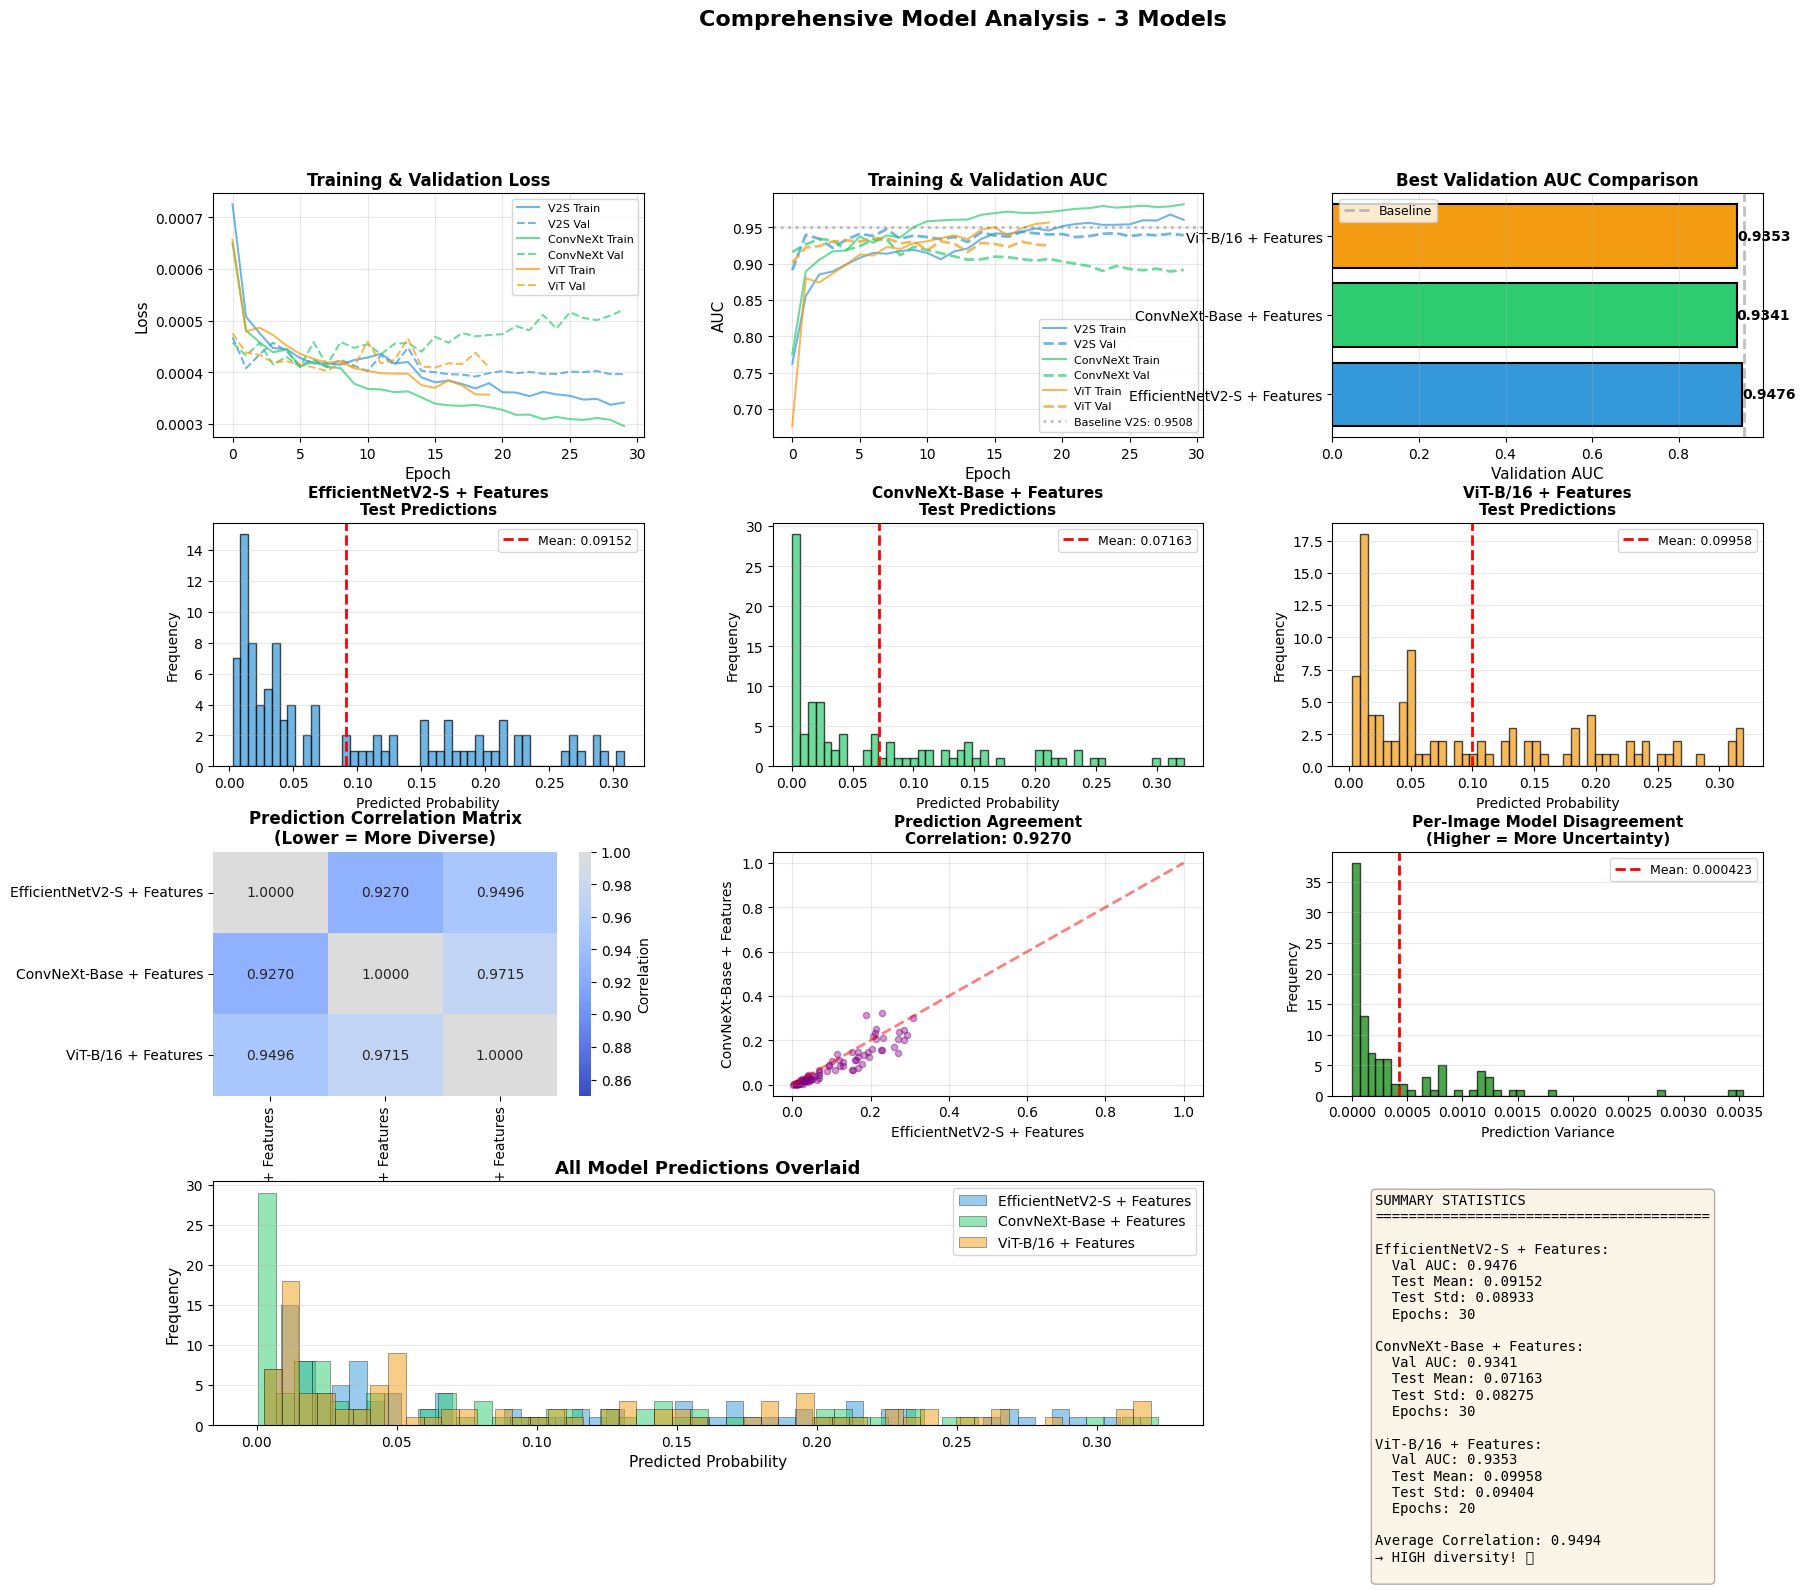

In [17]:
# ===========================
# VISUALIZATIONS
# ===========================

print("="*70)
print("GENERATING VISUALIZATIONS")
print("="*70 + "\n")

# Assign a unique color for each model
model_names = list(all_models.keys())
model_colors = {name: color for name, color in zip(model_names, ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6'])}

fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(4, 3, hspace=0.35, wspace=0.3)

# === ROW 1: TRAINING CURVES ===

# 1.1: Training Loss
ax_loss = fig.add_subplot(gs[0, 0])
for name, results in all_models.items():
    history = results['history']
    color = model_colors[name]
    ax_loss.plot(history['train_loss'], label=f"{name} Train", color=color, alpha=0.7)
    ax_loss.plot(history['val_loss'], label=f"{name} Val", color=color, linestyle='--', alpha=0.7)

ax_loss.set_xlabel('Epoch', fontsize=11)
ax_loss.set_ylabel('Loss', fontsize=11)
ax_loss.set_title('Training & Validation Loss', fontweight='bold', fontsize=12)
ax_loss.legend(fontsize=8)
ax_loss.grid(True, alpha=0.3)

# 1.2: Training AUC
ax_auc = fig.add_subplot(gs[0, 1])
for name, results in all_models.items():
    history = results['history']
    color = model_colors[name]
    ax_auc.plot(history['train_auc'], label=f"{name} Train", color=color, alpha=0.7)
    ax_auc.plot(history['val_auc'], label=f"{name} Val", color=color, linestyle='--', alpha=0.7, linewidth=2)

ax_auc.axhline(0.9508, color='gray', linestyle=':', linewidth=2, alpha=0.5, label='Baseline V2S: 0.9508')
ax_auc.set_xlabel('Epoch', fontsize=11)
ax_auc.set_ylabel('AUC', fontsize=11)
ax_auc.set_title('Training & Validation AUC', fontweight='bold', fontsize=12)
ax_auc.legend(fontsize=8)
ax_auc.grid(True, alpha=0.3)

# 1.3: Val AUC comparison bar chart
ax_bar = fig.add_subplot(gs[0, 2])
model_labels = [results['name'] for results in all_models.values()]
val_aucs = [results['val_auc'] for results in all_models.values()]
colors = [model_colors[name] for name in all_models.keys()]

bars = ax_bar.barh(range(len(all_models)), val_aucs, color=colors, edgecolor='black', linewidth=1.5)
ax_bar.set_yticks(range(len(all_models)))
ax_bar.set_yticklabels(model_labels, fontsize=10)
ax_bar.set_xlabel('Validation AUC', fontsize=11)
ax_bar.set_title('Best Validation AUC Comparison', fontweight='bold', fontsize=12)
ax_bar.axvline(0.9508, color='gray', linestyle='--', linewidth=2, alpha=0.5, label='Baseline')
ax_bar.legend(fontsize=9)
ax_bar.grid(True, alpha=0.3, axis='x')

for bar, auc in zip(bars, val_aucs):
    width = bar.get_width()
    ax_bar.text(width, bar.get_y() + bar.get_height()/2.,
               f'{auc:.4f}', ha='left', va='center', fontweight='bold', fontsize=10)

# === ROW 2: PREDICTION DISTRIBUTIONS ===

# 2.1-2.3: Individual model distributions
for idx, (name, results) in enumerate(all_models.items()):
    ax = fig.add_subplot(gs[1, idx])
    preds = results['test_predictions']
    color = model_colors[name]
    ax.hist(preds, bins=50, alpha=0.7, color=color, edgecolor='black')
    ax.axvline(preds.mean(), color='red', linestyle='--', linewidth=2,
              label=f'Mean: {preds.mean():.5f}')
    ax.set_xlabel('Predicted Probability', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(f'{results["name"]}\nTest Predictions', fontweight='bold', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

# === ROW 3: CORRELATION & DIVERSITY ===

if num_models >= 2:
    # 3.1: Correlation heatmap
    ax_corr = fig.add_subplot(gs[2, 0])
    sns.heatmap(corr_matrix, annot=True, fmt='.4f', cmap='coolwarm',
                xticklabels=model_labels, yticklabels=model_labels,
                ax=ax_corr, center=1.0, vmin=0.85, vmax=1.0,
                cbar_kws={'label': 'Correlation'})
    ax_corr.set_title('Prediction Correlation Matrix\n(Lower = More Diverse)', 
                     fontweight='bold', fontsize=12)
    
    # 3.2: Scatter plot (first two models)
    ax_scatter = fig.add_subplot(gs[2, 1])
    if num_models >= 2:
        name1, name2 = model_names[0], model_names[1]
        preds1 = all_models[name1]['test_predictions']
        preds2 = all_models[name2]['test_predictions']
        
        ax_scatter.scatter(preds1, preds2, alpha=0.4, s=20, color='purple')
        ax_scatter.plot([0, 1], [0, 1], 'r--', linewidth=2, alpha=0.5)
        
        corr_val = corr_matrix[0, 1]
        ax_scatter.set_xlabel(f'{all_models[name1]["name"]}', fontsize=10)
        ax_scatter.set_ylabel(f'{all_models[name2]["name"]}', fontsize=10)
        ax_scatter.set_title(f'Prediction Agreement\nCorrelation: {corr_val:.4f}', 
                           fontweight='bold', fontsize=11)
        ax_scatter.grid(True, alpha=0.3)
    
    # 3.3: Diversity analysis
    ax_div = fig.add_subplot(gs[2, 2])
    
    # Calculate per-image prediction variance
    pred_variance = np.var(pred_matrix, axis=1)
    
    ax_div.hist(pred_variance, bins=50, alpha=0.7, color='green', edgecolor='black')
    ax_div.axvline(pred_variance.mean(), color='red', linestyle='--', linewidth=2,
                  label=f'Mean: {pred_variance.mean():.6f}')
    ax_div.set_xlabel('Prediction Variance', fontsize=10)
    ax_div.set_ylabel('Frequency', fontsize=10)
    ax_div.set_title('Per-Image Model Disagreement\n(Higher = More Uncertainty)', 
                    fontweight='bold', fontsize=11)
    ax_div.legend(fontsize=9)
    ax_div.grid(True, alpha=0.3, axis='y')

# === ROW 4: COMPARATIVE DISTRIBUTIONS ===

# 4.1: All distributions overlaid
ax_all = fig.add_subplot(gs[3, :2])
for idx, (name, results) in enumerate(all_models.items()):
    preds = results['test_predictions']
    color = model_colors[name]
    ax_all.hist(preds, bins=50, alpha=0.5, label=results['name'], 
               color=color, edgecolor='black', linewidth=0.5)

ax_all.set_xlabel('Predicted Probability', fontsize=11)
ax_all.set_ylabel('Frequency', fontsize=11)
ax_all.set_title('All Model Predictions Overlaid', fontweight='bold', fontsize=13)
ax_all.legend(fontsize=10)
ax_all.grid(True, alpha=0.3, axis='y')

# 4.2: Summary statistics
ax_summary = fig.add_subplot(gs[3, 2])
ax_summary.axis('off')

summary_text = "SUMMARY STATISTICS\n" + "="*40 + "\n\n"

for name, results in all_models.items():
    preds = results['test_predictions']
    summary_text += f"{results['name']}:\n"
    summary_text += f"  Val AUC: {results['val_auc']:.4f}\n"
    summary_text += f"  Test Mean: {preds.mean():.5f}\n"
    summary_text += f"  Test Std: {preds.std():.5f}\n"
    summary_text += f"  Epochs: {len(results['history']['train_auc'])}\n\n"

if num_models >= 2:
    avg_corr = np.mean(corr_matrix[np.triu_indices_from(corr_matrix, k=1)])
    summary_text += f"Average Correlation: {avg_corr:.4f}\n"
    
    if avg_corr < 0.95:
        summary_text += "→ HIGH diversity! 🎉\n"
    elif avg_corr < 0.97:
        summary_text += "→ Good diversity ✓\n"
    else:
        summary_text += "→ Low diversity ⚠\n"

ax_summary.text(0.1, 0.95, summary_text, transform=ax_summary.transAxes,
               fontsize=10, verticalalignment='top', fontfamily='monospace',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle(f'Comprehensive Model Analysis - {num_models} Models', 
            fontsize=16, fontweight='bold', y=0.995)

# Save figure
analysis_dir = Path('results') / 'model_analysis'
analysis_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(analysis_dir / 'comprehensive_analysis.png', dpi=150, bbox_inches='tight')
print(f"\n✓ Comprehensive visualization saved: {analysis_dir / 'comprehensive_analysis.png'}\n")
plt.show()


In [13]:
# ===========================
# DETAILED ARCHITECTURE COMPARISON
# ===========================

print("\n" + "="*70)
print("ARCHITECTURE COMPARISON")
print("="*70 + "\n")

arch_comparison = {
    'V2S': {
        'Type': 'Efficient CNN',
        'Params': '21.5M',
        'Features': '1280',
        'Key': 'Compound scaling, mobile-optimized',
        'Strength': 'Efficient, proven medical imaging'
    },
    'ConvNeXt': {
        'Type': 'Modern CNN',
        'Params': '88M',
        'Features': '1024',
        'Key': 'Larger kernels, LayerNorm, GELU',
        'Strength': 'Competes with transformers, texture-rich'
    },
    'ViT': {
        'Type': 'Pure Transformer',
        'Params': '86M',
        'Features': '768',
        'Key': 'Self-attention, no convolutions',
        'Strength': 'Global context, different biases'
    }
}

print("Architecture Details:")
print("-" * 70)
for name, results in all_models.items():
    if name in arch_comparison:
        arch = arch_comparison[name]
        print(f"\n{results['name']}:")
        print(f"  Type:      {arch['Type']}")
        print(f"  Params:    {arch['Params']}")
        print(f"  Features:  {arch['Features']}")
        print(f"  Key Tech:  {arch['Key']}")
        print(f"  Strength:  {arch['Strength']}")
        print(f"  Val AUC:   {results['val_auc']:.4f}")

print("\n" + "-" * 70)
print()


ARCHITECTURE COMPARISON

Architecture Details:
----------------------------------------------------------------------

EfficientNetV2-S + Features:
  Type:      Efficient CNN
  Params:    21.5M
  Features:  1280
  Key Tech:  Compound scaling, mobile-optimized
  Strength:  Efficient, proven medical imaging
  Val AUC:   0.9476

ConvNeXt-Base + Features:
  Type:      Modern CNN
  Params:    88M
  Features:  1024
  Key Tech:  Larger kernels, LayerNorm, GELU
  Strength:  Competes with transformers, texture-rich
  Val AUC:   0.9341

ViT-B/16 + Features:
  Type:      Pure Transformer
  Params:    86M
  Features:  768
  Key Tech:  Self-attention, no convolutions
  Strength:  Global context, different biases
  Val AUC:   0.9353

----------------------------------------------------------------------



In [14]:
# ===========================
# IDENTIFY BEST & MOST DIVERSE
# ===========================

print("="*70)
print("MODEL RANKINGS")
print("="*70 + "\n")

# Rank by validation AUC
sorted_by_auc = sorted(all_models.items(), key=lambda x: x[1]['val_auc'], reverse=True)

print("Ranked by Validation AUC:")
for rank, (name, results) in enumerate(sorted_by_auc, 1):
    print(f"  {rank}. {results['name']}: {results['val_auc']:.4f}")
print()

# Identify most diverse model
if num_models >= 2:
    diversity_scores = []
    for i, name in enumerate(model_names):
        avg_corr = (corr_matrix[i].sum() - 1) / (num_models - 1)
        diversity = 1 - avg_corr
        diversity_scores.append((name, diversity))
    
    diversity_scores.sort(key=lambda x: x[1], reverse=True)
    
    print("Ranked by Diversity (most different from others):")
    for rank, (name, div) in enumerate(diversity_scores, 1):
        print(f"  {rank}. {all_models[name]['name']}: {div:.4f}")
    print()

MODEL RANKINGS

Ranked by Validation AUC:
  1. EfficientNetV2-S + Features: 0.9476
  2. ViT-B/16 + Features: 0.9353
  3. ConvNeXt-Base + Features: 0.9341

Ranked by Diversity (most different from others):
  1. EfficientNetV2-S + Features: 0.0617
  2. ConvNeXt-Base + Features: 0.0508
  3. ViT-B/16 + Features: 0.0395



Generating additional detailed plots...

✓ Training AUC plot saved: training_auc_detailed.png
✓ Training AUC plot saved: training_auc_detailed.png


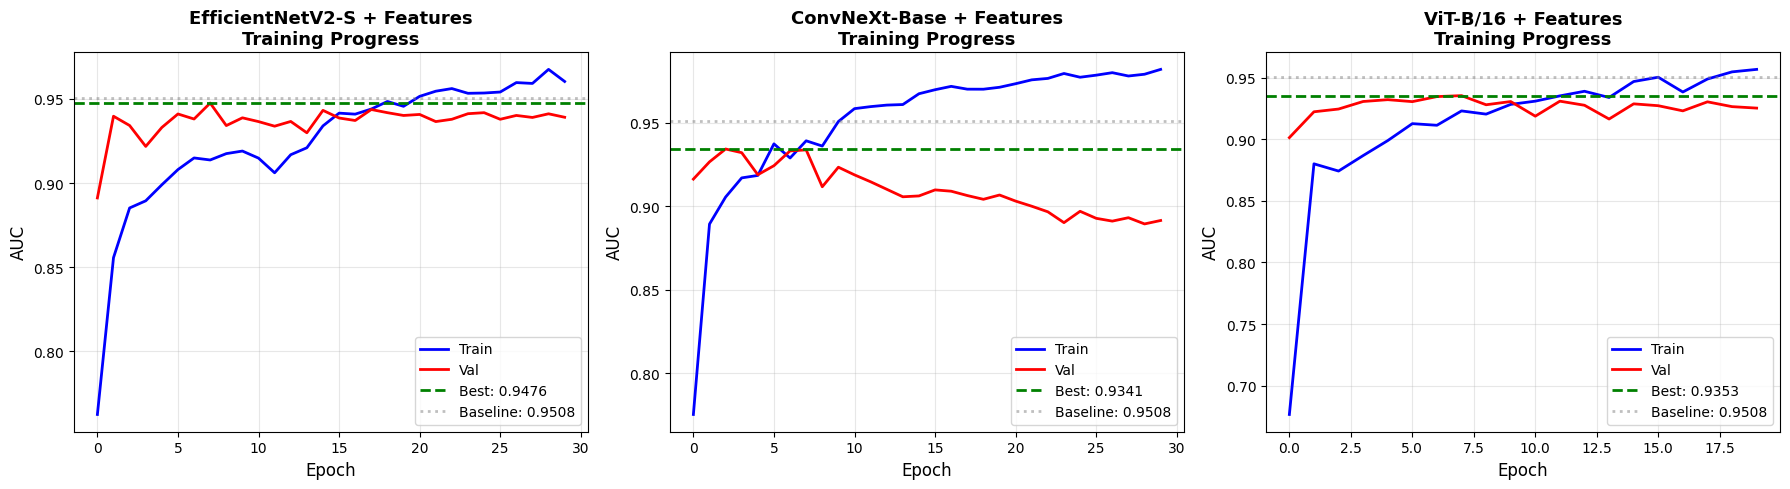

✓ Scatter matrix saved: scatter_matrix.png


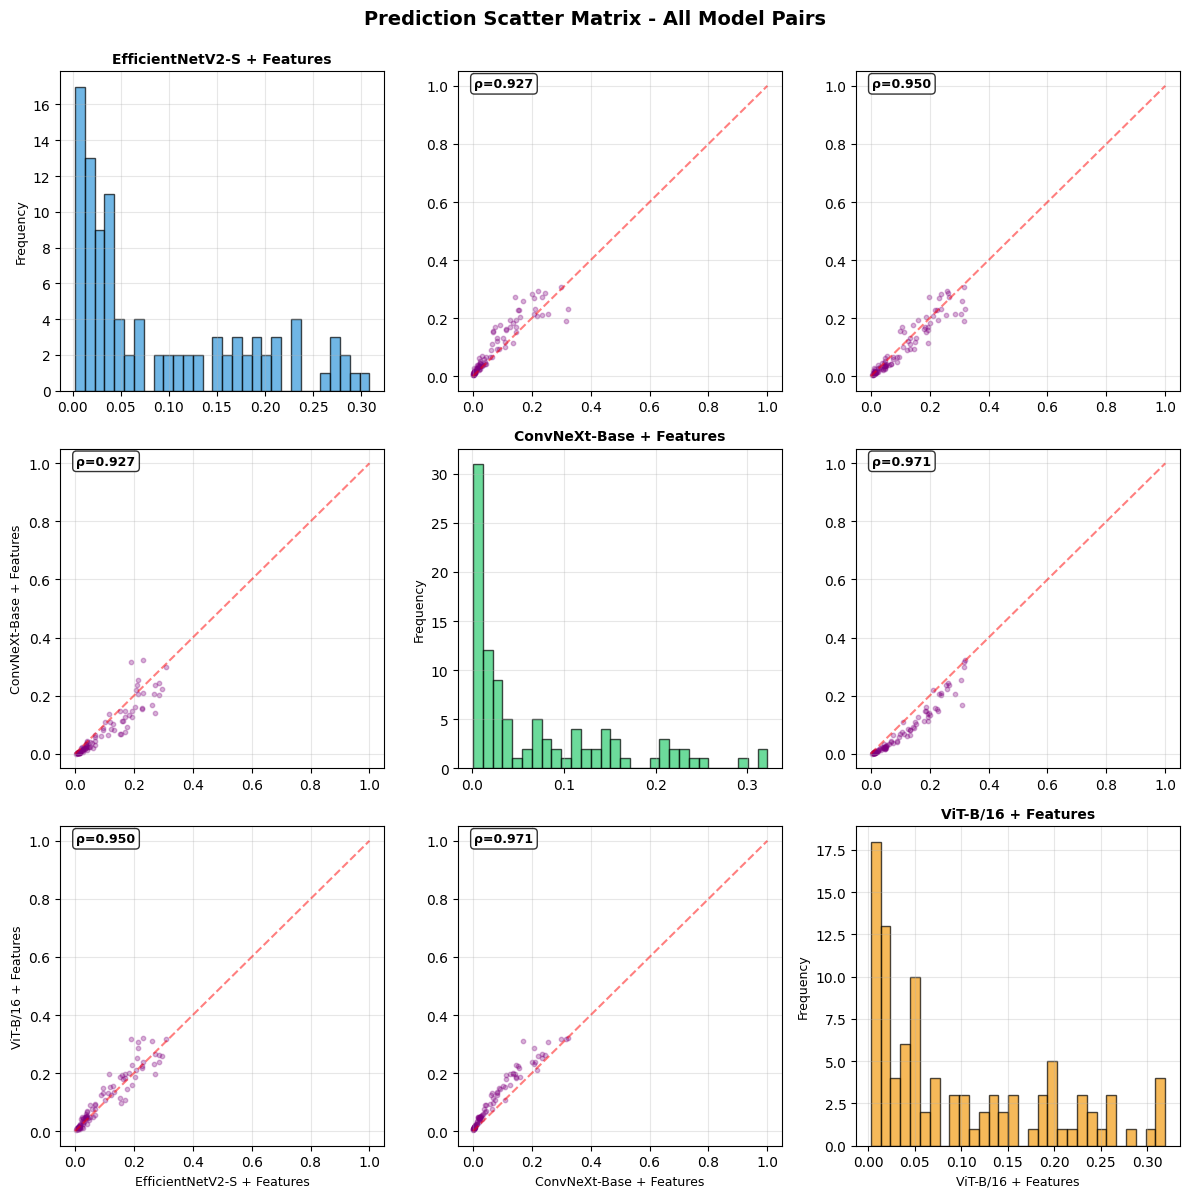

✓ Agreement analysis saved: model_agreement_analysis.png


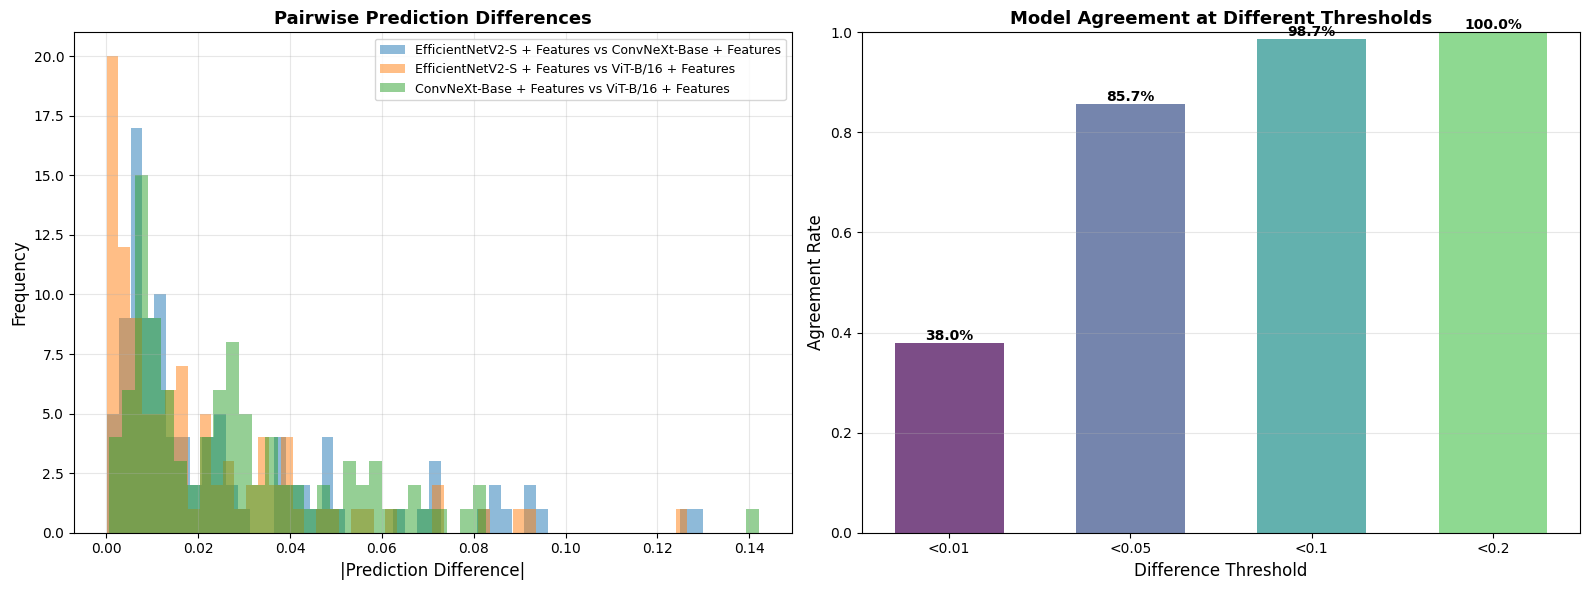

In [19]:
# ===========================
# ADDITIONAL DETAILED PLOTS
# ===========================

print("Generating additional detailed plots...\n")

# Plot 1: Training AUC progression (larger view)
fig, axes = plt.subplots(1, num_models, figsize=(6*num_models, 5))
if num_models == 1:
    axes = [axes]

for idx, (name, results) in enumerate(all_models.items()):
    history = results['history']
    
    axes[idx].plot(history['train_auc'], 'b-', label='Train', linewidth=2)
    axes[idx].plot(history['val_auc'], 'r-', label='Val', linewidth=2)
    axes[idx].axhline(results['val_auc'], color='green', linestyle='--', 
                     linewidth=2, label=f"Best: {results['val_auc']:.4f}")
    axes[idx].axhline(0.9508, color='gray', linestyle=':', linewidth=2, 
                     alpha=0.5, label='Baseline: 0.9508')
    
    axes[idx].set_xlabel('Epoch', fontsize=12)
    axes[idx].set_ylabel('AUC', fontsize=12)
    axes[idx].set_title(f'{results["name"]}\nTraining Progress', fontweight='bold', fontsize=13)
    axes[idx].legend(fontsize=10)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(analysis_dir / 'training_auc_detailed.png', dpi=150, bbox_inches='tight')
print(f"✓ Training AUC plot saved: training_auc_detailed.png")
plt.show()

# Plot 2: Prediction comparison scatter matrix
if num_models >= 2:
    fig, axes = plt.subplots(num_models, num_models, figsize=(4*num_models, 4*num_models))
    
    for i in range(num_models):
        for j in range(num_models):
            ax = axes[i, j] if num_models > 1 else axes
            
            if i == j:
                # Diagonal: histogram
                preds = all_models[model_names[i]]['test_predictions']
                ax.hist(preds, bins=30, alpha=0.7, color=colors[i], edgecolor='black')
                ax.set_ylabel('Frequency', fontsize=9)
                ax.set_title(all_models[model_names[i]]['name'], fontsize=10, fontweight='bold')
            else:
                # Off-diagonal: scatter plot
                preds_x = all_models[model_names[j]]['test_predictions']
                preds_y = all_models[model_names[i]]['test_predictions']
                
                ax.scatter(preds_x, preds_y, alpha=0.3, s=10, color='purple')
                ax.plot([0, 1], [0, 1], 'r--', linewidth=1.5, alpha=0.5)
                
                corr_val = corr_matrix[i, j]
                ax.text(0.05, 0.95, f'ρ={corr_val:.3f}', 
                       transform=ax.transAxes, fontsize=9, fontweight='bold',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            
            ax.grid(True, alpha=0.3)
            
            # Labels only on edges
            if i == num_models - 1:
                ax.set_xlabel(all_models[model_names[j]]['name'], fontsize=9)
            if j == 0 and i != j:
                ax.set_ylabel(all_models[model_names[i]]['name'], fontsize=9)
    
    plt.suptitle('Prediction Scatter Matrix - All Model Pairs', 
                fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(analysis_dir / 'scatter_matrix.png', dpi=150, bbox_inches='tight')
    print(f"✓ Scatter matrix saved: scatter_matrix.png")
    plt.show()

# Plot 3: Model agreement levels
if num_models >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 3.1: Histogram of pairwise differences
    ax = axes[0]
    for i in range(num_models):
        for j in range(i+1, num_models):
            name1, name2 = model_names[i], model_names[j]
            preds1 = all_models[name1]['test_predictions']
            preds2 = all_models[name2]['test_predictions']
            
            diff = np.abs(preds1 - preds2)
            ax.hist(diff, bins=50, alpha=0.5, 
                   label=f'{all_models[name1]["name"]} vs {all_models[name2]["name"]}')
    
    ax.set_xlabel('|Prediction Difference|', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Pairwise Prediction Differences', fontweight='bold', fontsize=13)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # 3.2: Agreement levels
    ax = axes[1]
    
    # Calculate agreement at different thresholds
    thresholds = [0.01, 0.05, 0.10, 0.20]
    agreement_data = {thresh: [] for thresh in thresholds}
    
    for i in range(num_models):
        for j in range(i+1, num_models):
            preds1 = all_models[model_names[i]]['test_predictions']
            preds2 = all_models[model_names[j]]['test_predictions']
            diff = np.abs(preds1 - preds2)
            
            for thresh in thresholds:
                agreement = (diff < thresh).mean()
                agreement_data[thresh].append(agreement)
    
    x = np.arange(len(thresholds))
    for idx, thresh in enumerate(thresholds):
        agreements = agreement_data[thresh]
        ax.bar(x[idx], np.mean(agreements), width=0.6, 
              alpha=0.7, label=f'Threshold: {thresh}',
              color=plt.cm.viridis(idx/len(thresholds)))
    
    ax.set_xticks(x)
    ax.set_xticklabels([f'<{t}' for t in thresholds])
    ax.set_ylabel('Agreement Rate', fontsize=12)
    ax.set_xlabel('Difference Threshold', fontsize=12)
    ax.set_title('Model Agreement at Different Thresholds', fontweight='bold', fontsize=13)
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add percentage labels on bars
    for idx, thresh in enumerate(thresholds):
        val = np.mean(agreement_data[thresh])
        ax.text(x[idx], val, f'{val*100:.1f}%', 
               ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(analysis_dir / 'model_agreement_analysis.png', dpi=150, bbox_inches='tight')
    print(f"✓ Agreement analysis saved: model_agreement_analysis.png")
    plt.show()

In [ ]:
# ===========================
# SAVE INDIVIDUAL SUBMISSIONS (FOR REFERENCE)
# ===========================

print("\n" + "="*70)
print("SAVING INDIVIDUAL SUBMISSIONS")
print("="*70 + "\n")

for name, results in all_models.items():
    submission = pd.DataFrame({
        'isic_id': results['test_ids'],
        'target': results['test_predictions']
    })
    
    filename = f"submission_{name.lower()}_analyzed.csv"
    submission.to_csv(analysis_dir / filename, index=False)
    print(f"✓ {filename}")

print()

In [ ]:
# ===========================
# PLACEHOLDER: ENSEMBLE CODE TO BE ADDED
# ===========================

print("\n" + "="*70)
print("ENSEMBLE SECTION (TO BE IMPLEMENTED)")
print("="*70 + "\n")

print("TODO: Add ensemble strategies here:")
print("  - Correlation-weighted ensemble")
print("  - Architecture-weighted ensemble")
print("  - Rank-based ensemble")
print("  - Stacking (if needed)")
print("\nRun the separate ensemble_diverse_models.py script for now.")
print()